In [4]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_fiber_assignment_ELG')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

### AbacusHF mocks with different weights (standard, NN)

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0/abacus-hf-dr2-v2-altmtl/mock0/mesh2_spectrum_poles_ELG_LOPnotqso_z0.8-1.1_NGC_weight-default.h5


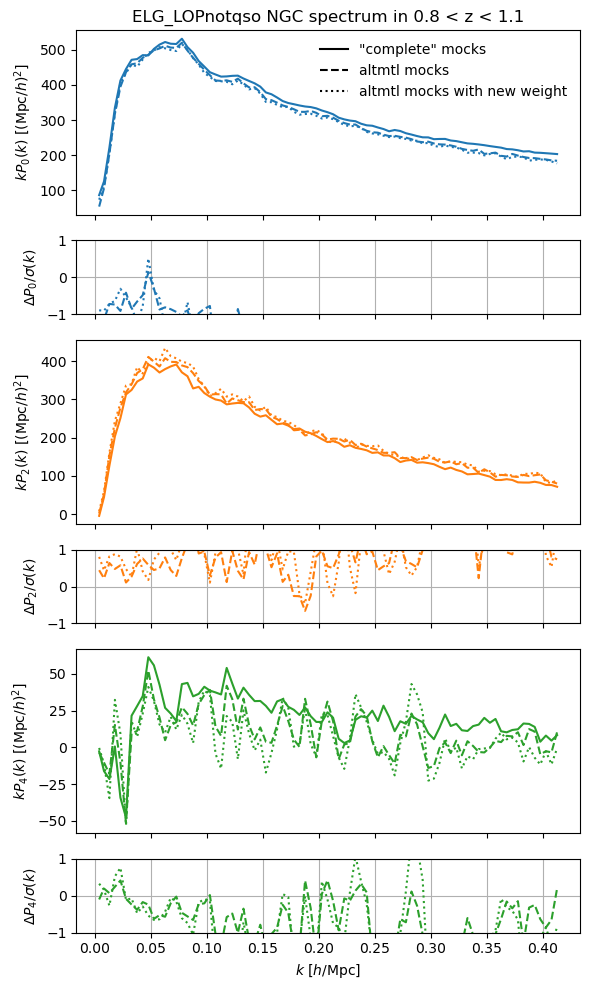

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0/abacus-hf-dr2-v2-altmtl/mock0/mesh2_spectrum_poles_ELG_LOPnotqso_z1.1-1.6_NGC_weight-default.h5


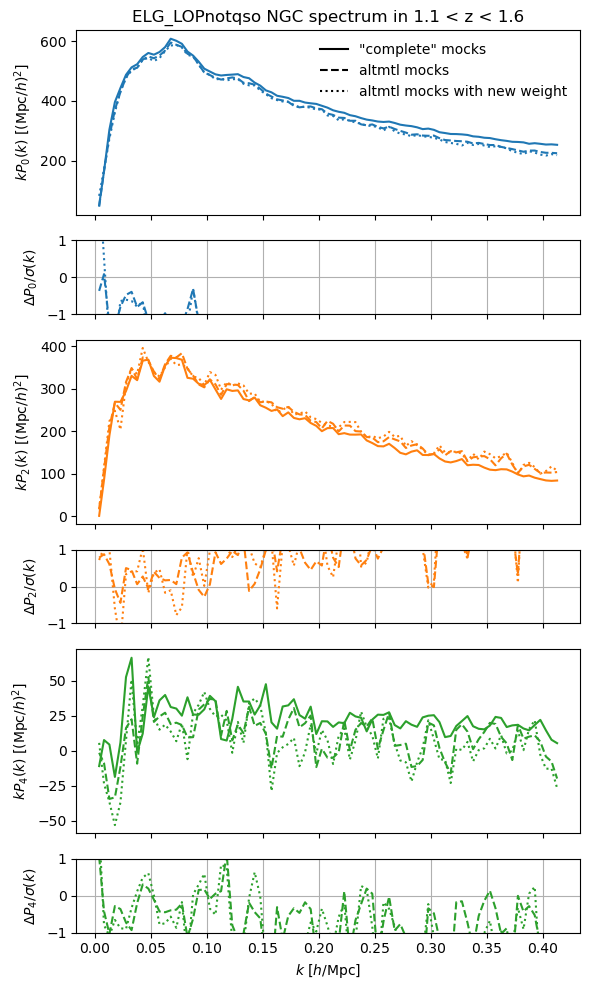

In [5]:
for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            nmocks = 2
            version = 'abacus-hf-dr2-v2-altmtl'
            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            project = 'full_shape/fiber_assignment_systematics_ELG_tilelocid-LRG0'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            print(fns[0])
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_nn = types.mean(mocks).match(mean)

            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with NN weight')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    #ax.set_ylim(-5e4, 5e4)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() #/ nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(k, (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
                ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_nn_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

### Glam-Uchuu mocks with different weights (standard, NN)

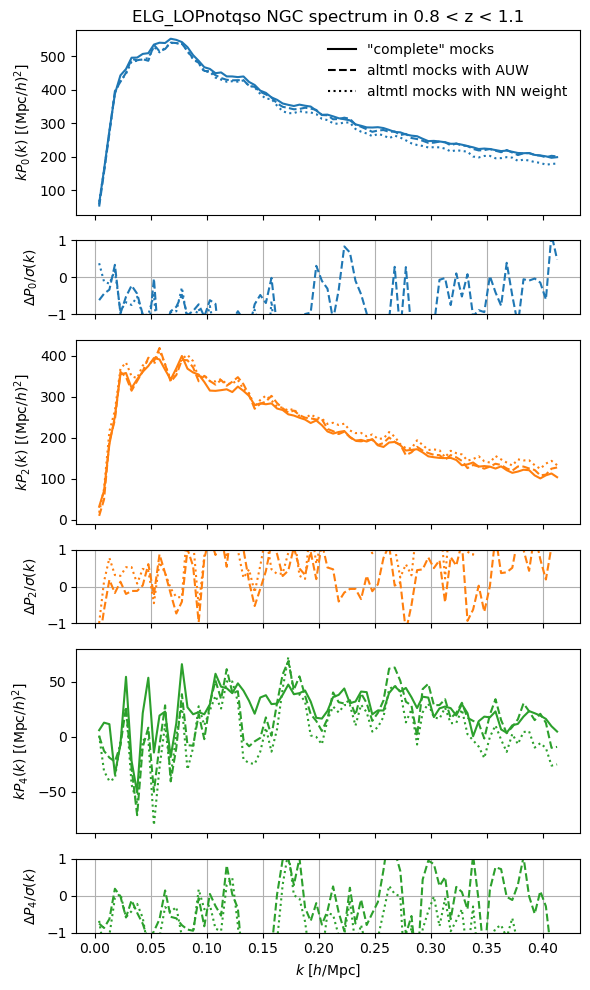

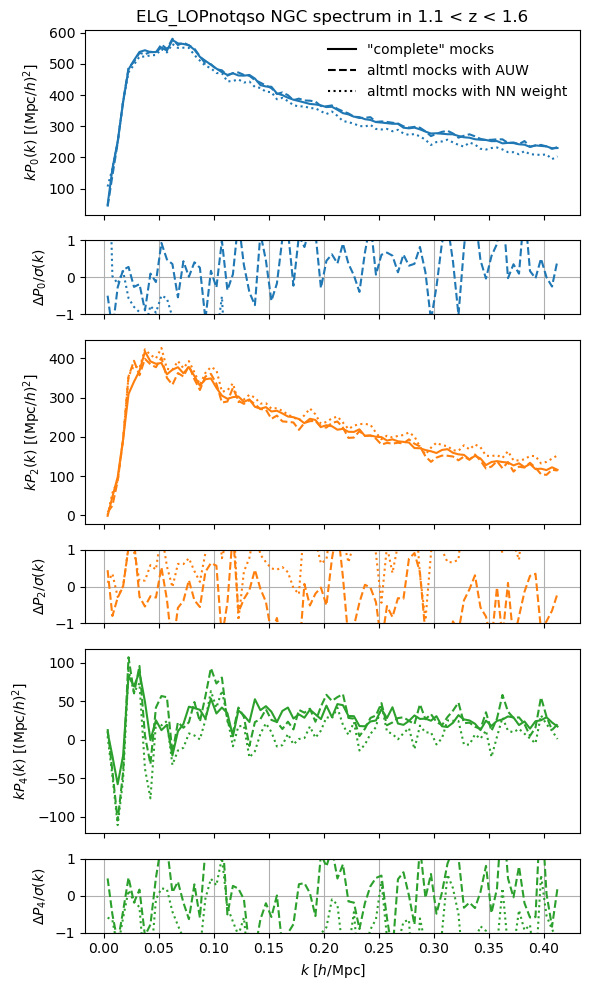

In [15]:
for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            imocks = [150]
            version = 'glam-uchuu-v2-altmtl'
            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True, imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            version = 'glam-uchuu-v2-altmtl-maskedfraczpNN'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_nn = types.mean(mocks).match(mean)

            version = 'glam-uchuu-v2-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks with AUW')
                ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with NN weight')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_nn_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

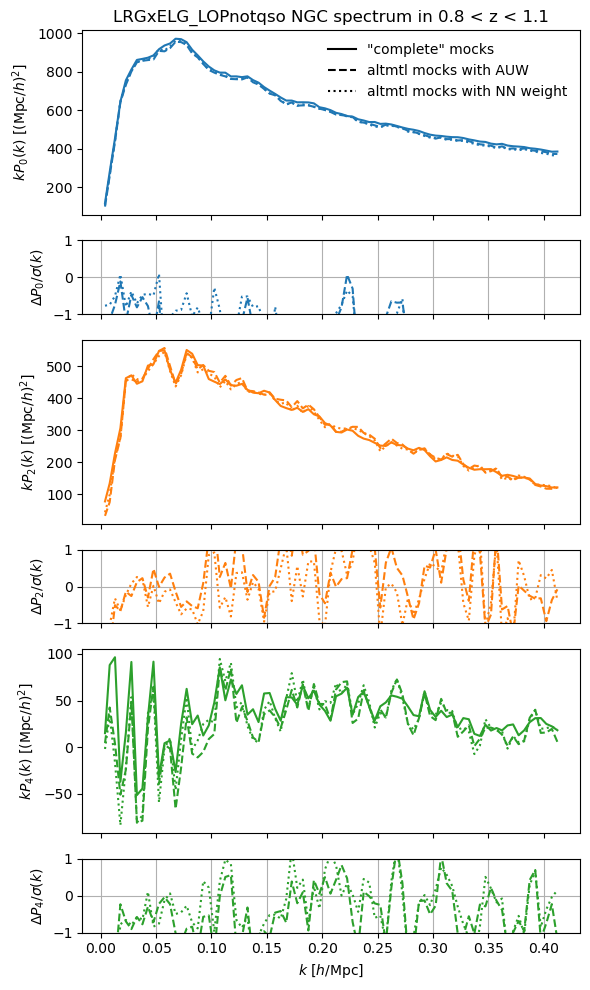

In [38]:
for tracer in [('LRG', 'ELG_LOPnotqso')]:
    for zrange in [(0.8, 1.1)]:
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer[1],
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            imocks = [150]
            version = 'glam-uchuu-v2-altmtl'
            project = 'full_shape/fiber_assignment_systematics'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True, imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            version = ('glam-uchuu-v2-altmtl', 'glam-uchuu-v2-altmtl-maskedfraczpNN')
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_nn = types.mean(mocks).match(mean)

            version = 'glam-uchuu-v2-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', extra='complete',
                                      imock=imock) for imock in imocks]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{"x".join(tracer)} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    pole = mean_complete.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-1., 1.)
                    pole = mean.get(ell)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole_complete = mean_complete.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                    pole = mean_nn.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='"complete" mocks')
                ax.plot([], [], color='k', linestyle='--', label='altmtl mocks with AUW')
                ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with NN weight')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_nn_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/fiber_assignment_systematics/glam-uchuu-v2-altmtl/mock150/particle2_angular_upweights_LRGxELG_LOPnotqso_z0.8-1.1_NGC_weight-default-FKP.h5


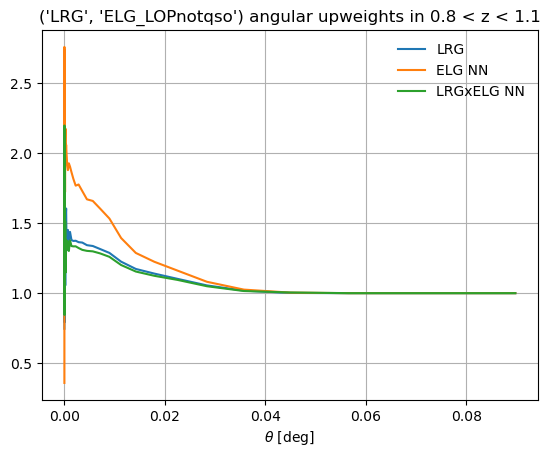

In [35]:
tracer = ('LRG', 'ELG_LOPnotqso')
for kind in ['particle2_angular_upweights']:
    stats_dir = tools.base_stats_dir
    project = 'full_shape/fiber_assignment_systematics'
    region = 'NGC'
    version = 'glam-uchuu-v2-altmtl'
    imock = 150
    angular_data = []
    fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version,
                            zrange=zrange, tracer=tracer[0], region=region, weight='default-FKP', imock=imock)
    angular_data.append(types.read(fn))
    fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version,
                            zrange=zrange, tracer=tracer[1], region=region, weight='default-FKP', imock=imock)
    angular_data.append(types.read(fn))
    fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version,
                            zrange=zrange, tracer=tracer, region=region, weight='default-FKP', imock=imock)
    print(fn)
    angular_data.append(types.read(fn))
    if 'particle2' in kind:
        fig, ax = plt.subplots()
        angular = angular_data[0].get('DD')
        ax.plot(angular.coords('theta'), angular.value(), color='C0', linestyle='-', label='LRG')
        angular = angular_data[1].get('DD')
        ax.plot(angular.coords('theta'), angular.value(), color='C1', linestyle='-', label='ELG NN')
        angular = angular_data[2].get('DD')
        ax.plot(angular.coords('theta'), angular.value(), color='C2', linestyle='-', label='LRGxELG NN')
        ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
        ax.grid(True)
        ax.legend(frameon=False)
        ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')

In [30]:
plt.close('all')

### Abacusv2 mocks with different weights (standard, NN)

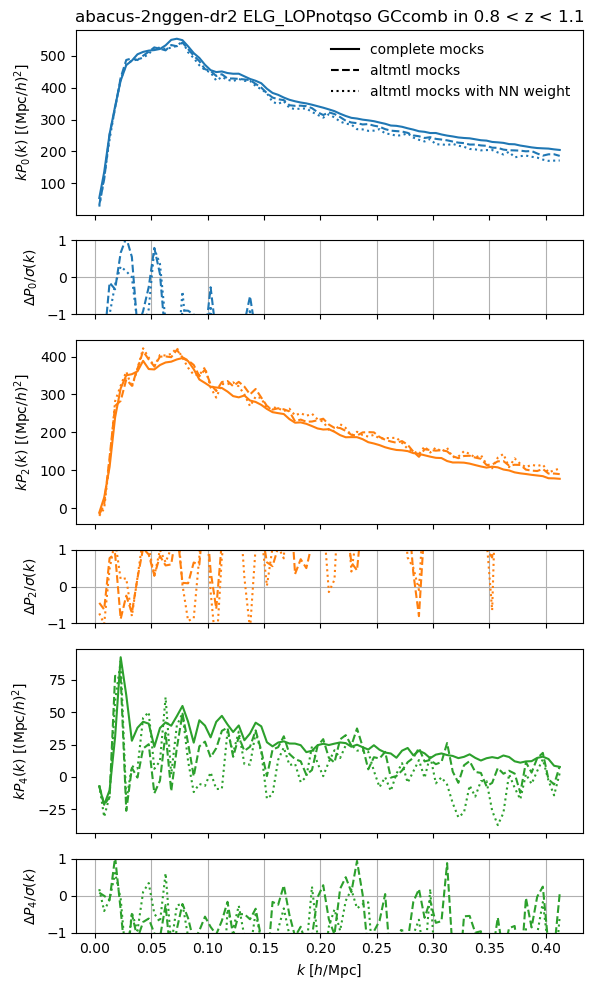

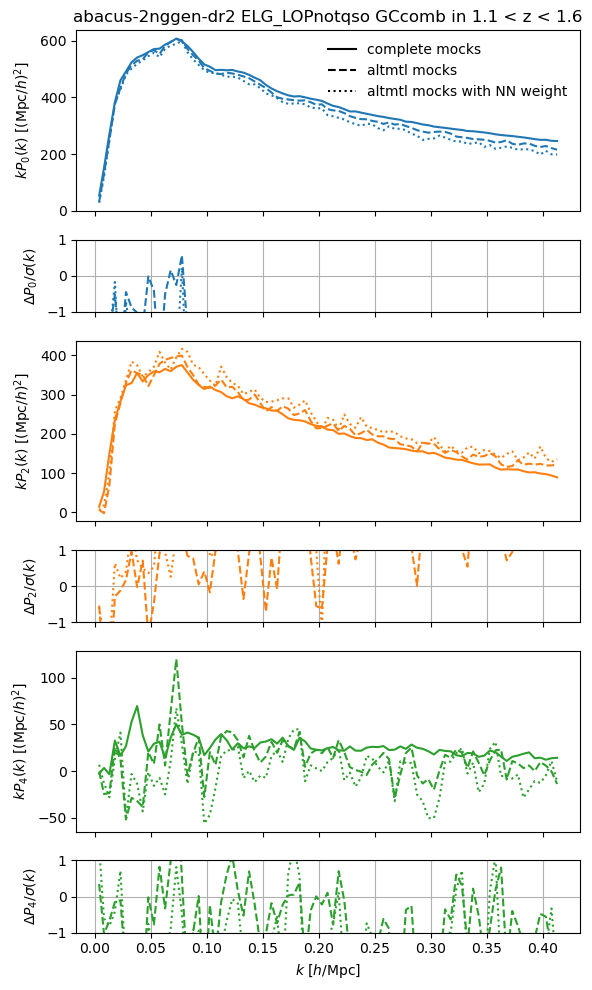

In [36]:
# the comparisons of abacus-2nggen-dr2-complete, abacus-2nggen-dr2-altmtl with AUW, and  abacus-2nggen-dr2-altmtl with AUW and nearest neibourgh weights
mocktype = 'abacus-2nggen-dr2'

for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'GCcomb'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            nmocks = 2
            version = 'abacus-2ndgen-dr2-complete'
            project = 'full_shape/base'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer='ELG_LOP',
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_complete = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            stats_dir = "/global/cfs/cdirs/desi/users/jiaxiyu/fiber_assignment_systematics_ELG_nn/pk"
            nmocks = 1
            version = './'
            project = 'old_FA'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP_0', basis='sugiyama-diagonal')]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)

            project = 'nn_FA'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP_0', basis='sugiyama-diagonal')]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_nn = types.mean(mocks).match(mean)

            ells = mean.ells
            fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
            lax[0].set_title(f'{mocktype} {tracer} {region} in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            for ill, ell in enumerate(mean.ells):

                ax = lax[2 * ill]
                ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                color = f'C{ill:d}'
                pole = mean_complete.get(ell)
                ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                pole = mean.get(ell)
                ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                pole = mean_nn.get(ell)
                ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')

                ax = lax[2 * ill + 1]
                ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                ax.grid(True)
                ax.set_ylim(-1., 1.)
                pole = mean.get(ell)
                std = cov.at.observable.get(ell).std() # / nmocks**0.5
                pole_complete = mean_complete.get(ell)
                ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle='--')
                pole = mean_nn.get(ell)                
                ax.plot(pole.coords('k'), (pole.value() - pole_complete.value()) / std, color=color, linestyle=':')

            ax = lax[0]
            ax.plot([], [], color='k', linestyle='-', label='complete mocks')
            ax.plot([], [], color='k', linestyle='--', label='altmtl mocks')
            ax.plot([], [], color='k', linestyle=':', label='altmtl mocks with NN weight')
            lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
            ax.legend(frameon=False)

            basename = f'validation_nn_{kind}_{tracer}_{mocktype}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()